In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pearsonr

In [38]:
df = pd.read_csv('course_final.csv')

In [39]:
funnel = {
    "registered": len(df),
    "viewed": df["viewed"].sum(),
    "explored": df["explored"].sum(),
}

funnel_df = pd.DataFrame.from_dict(funnel, orient="index", columns=["count"])
funnel_df["conversion_rate"] = funnel_df["count"] / funnel_df.iloc[0,0]

print(funnel_df)

             count  conversion_rate
registered  533993         1.000000
viewed      325361         0.609298
explored     37584         0.070383


In [40]:
df["drop_view"] = (df["viewed"] == 0)
df["drop_explore"] = (df["viewed"] == 1) & (df["explored"] == 0)

print(df[["drop_view", "drop_explore",]].mean())

drop_view       0.390702
drop_explore    0.538915
dtype: float64


변수들에 대한 기본 분포 확인

In [41]:
# 분석 대상 변수
funnel_cols = ["viewed", "explored"]
behavior_cols = ["nchapters", "nplay_video", "nevents", "ndays_act", "nforum_posts"]
demo_cat_cols = ["age_group", "LoE_DI", "gender"]

In [42]:
# age는 연속형 demographic
demo_cont_cols = ["age"]

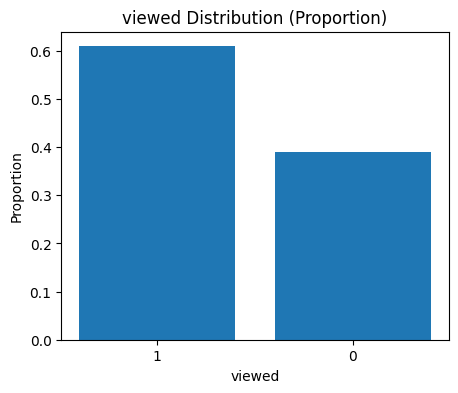

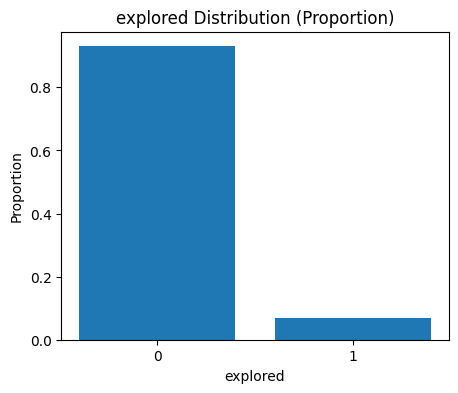

In [43]:

funnel_cols = ["viewed", "explored"]

for col in funnel_cols:
    counts = df[col].value_counts(normalize=True)

    plt.figure(figsize=(5,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"{col} Distribution (Proportion)")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.grid(False)
    plt.show()

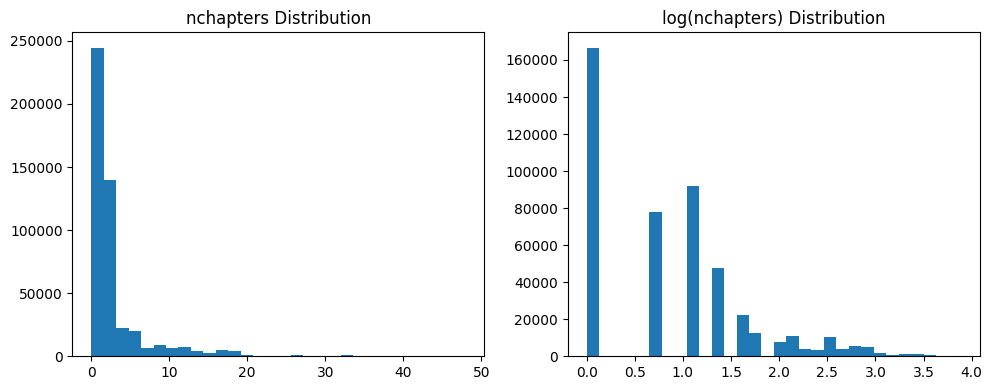

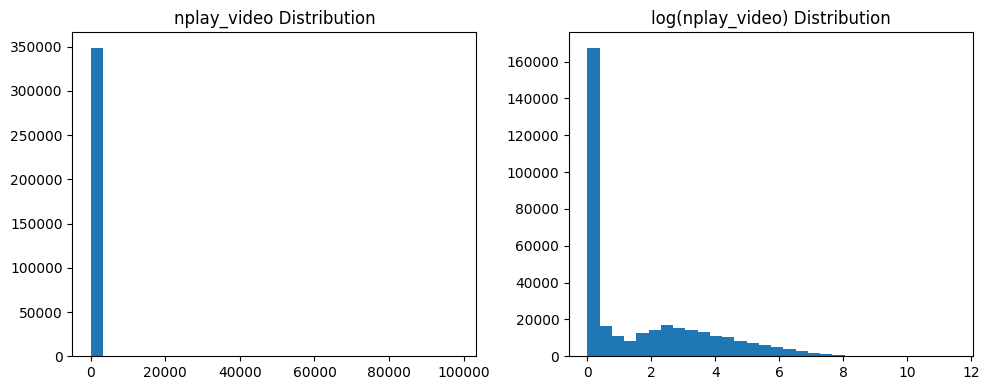

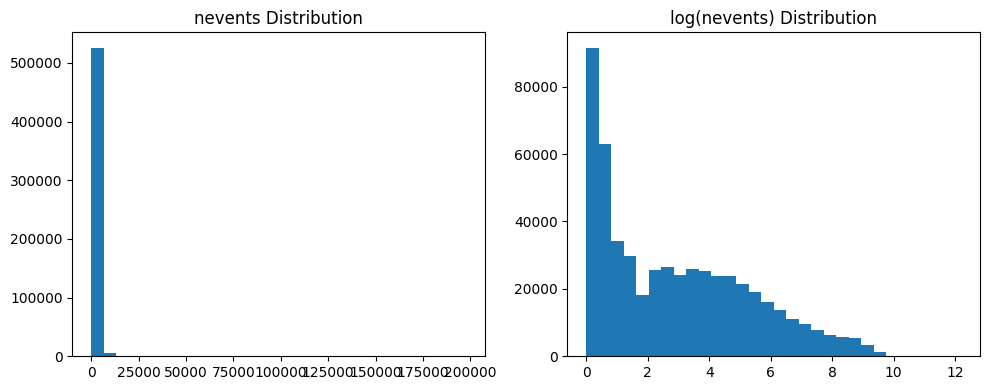

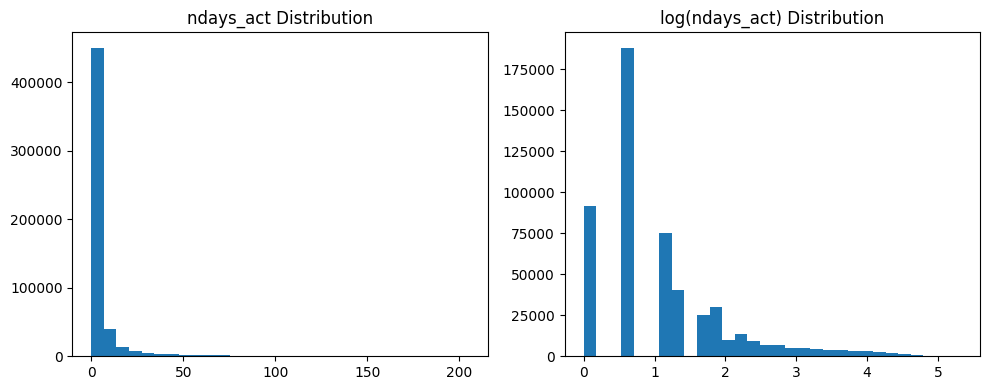

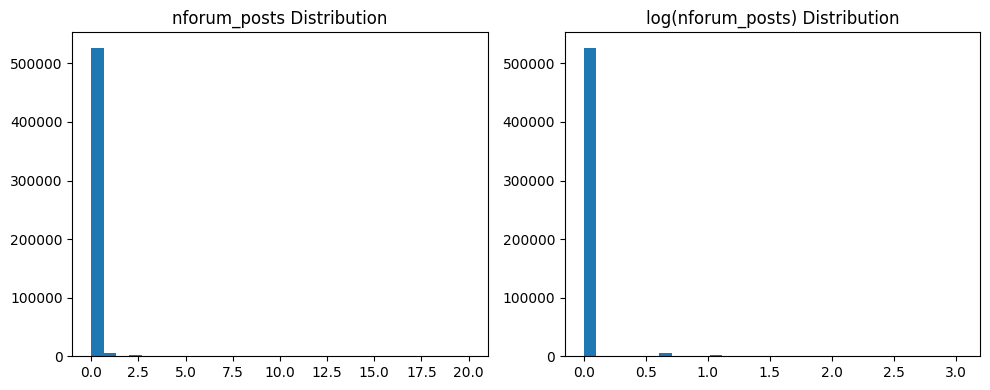

In [44]:
for col in behavior_cols:
    plt.figure(figsize=(10,4))

    # 원본
    plt.subplot(1,2,1)
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"{col} Distribution")

    # 로그 변환
    plt.subplot(1,2,2)
    plt.hist(np.log1p(df[col].dropna()), bins=30)
    plt.title(f"log({col}) Distribution")

    plt.tight_layout()
    plt.show()

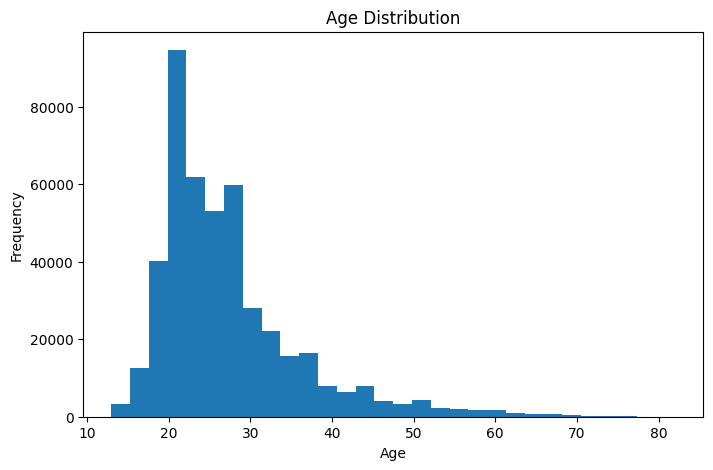

In [45]:
plt.figure(figsize=(8,5))
plt.hist(df["age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()

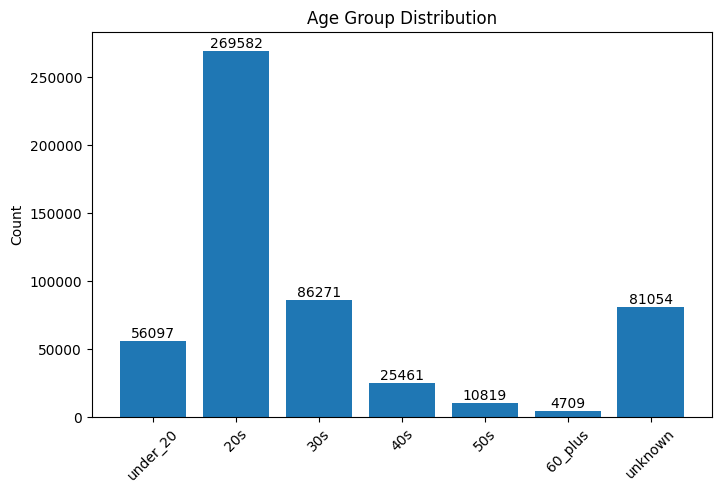

In [46]:
order = ["under_20", "20s", "30s", "40s", "50s", "60_plus", "unknown"]

age_counts = (
    df["age_group"]
    .value_counts()
    .reindex(order)
)

plt.figure(figsize=(8,5))
plt.bar(age_counts.index.astype(str), age_counts.values)
plt.title("Age Group Distribution")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.grid(False)

for i, v in enumerate(age_counts.values):
    if not pd.isna(v):
        plt.text(i, v, str(int(v)), ha='center', va='bottom')
plt.show()

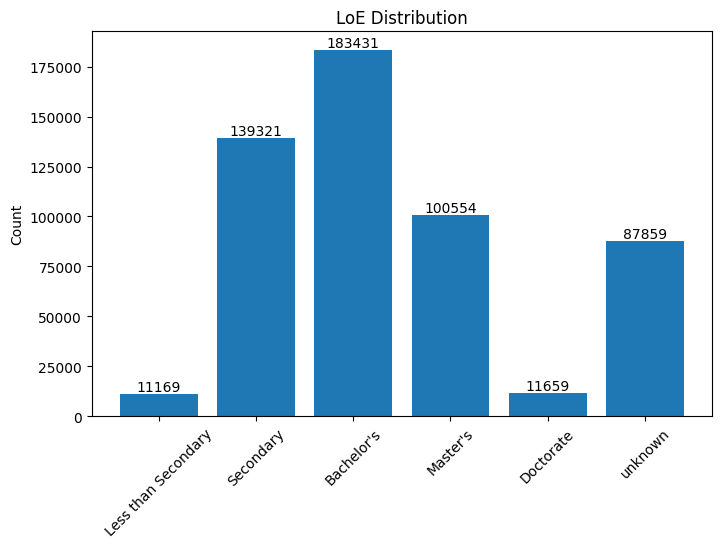

In [47]:
order = [
    "Less than Secondary",
    "Secondary",
    "Bachelor's",
    "Master's",
    "Doctorate",
    "unknown"
]

loe_counts = (
    df["LoE_DI"]
    .value_counts()
    .reindex(order)
)

plt.figure(figsize=(8,5))
plt.bar(loe_counts.index.astype(str), loe_counts.values)

plt.title("LoE Distribution")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.grid(False)

for i, v in enumerate(loe_counts.values):
    if not pd.isna(v):
        plt.text(i, v, str(int(v)), ha='center', va='bottom')

plt.show()

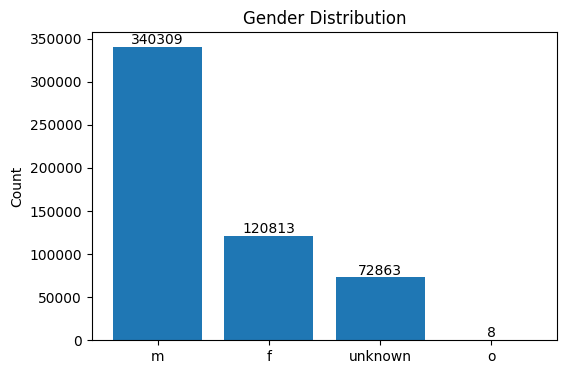

In [48]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender_counts.index.astype(str), gender_counts.values)
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.grid(False)

for i, v in enumerate(gender_counts.values):
    if not pd.isna(v):
        plt.text(i, v, str(int(v)), ha='center', va='bottom')

plt.show()

viewed vs demographic, activity

In [51]:
df.groupby("age_group")["viewed"].mean()

age_group
20s         0.594450
30s         0.577598
40s         0.569459
50s         0.588871
60_plus     0.650032
under_20    0.633082
unknown     0.688837
Name: viewed, dtype: float64

30~40대에서 상대적으로 낮은 viewed 비율이 나타난 반면, 20세 미만 및 60세 이상 집단에서는 높은 진입률이 관찰되었다.

In [52]:
df.groupby("LoE_DI")["viewed"].mean()

LoE_DI
Bachelor's             0.578059
Doctorate              0.634102
Less than Secondary    0.675978
Master's               0.603924
Secondary              0.608889
unknown                0.669550
Name: viewed, dtype: float64

학위 수준별 분석에서는 낮은 학력 집단에서 상대적으로 높은 viewed 비율이 나타나는 경향이 확인되었다. 반면, Bachelor's 수준에서는 가장 낮은 진입률이 관찰되었다.

In [ ]:
df.groupby("gender")["viewed"].mean()

gender
f          0.557746
m          0.609340
o          0.500000
unknown    0.694591
Name: viewed, dtype: float64

남성 학습자의 진입률(약 60.9%)이 여성(약 55.8%)보다 조금 높은 것(5%)으로 나타났다.

In [50]:
df.groupby("viewed")[behavior_cols].mean()

,nchapters,nplay_video,nevents,ndays_act,nforum_posts
viewed,,,,,
0,0.020916,0.002314,1.754309,0.709675,0.000240
1,4.075653,116.100900,587.189063,7.478801,0.037023


viewed 여부에 따라 행동 변수들을 비교한 결과, viewed=0인 경우 대부분의 활동 지표(nchapters, nplay_video, nevents, ndays_act, nforum_posts)가 거의 0에 가까운 수준을 보였으며, viewed=1인 경우에만 유의미한 활동이 발생하는 것으로 나타났다.

### viewed=1, 왜 어떤 사람은 explored 가고 어떤 사람은 안 가는가?

In [53]:
# viewed 만 분석
df_v = df[df["viewed"] == 1].copy()

In [54]:
behavior_cols = ["nchapters", "nplay_video", "nevents", "ndays_act", "nforum_posts"]

df_v.groupby("explored")[behavior_cols].median()

,nchapters,nplay_video,nevents,ndays_act,nforum_posts
explored,,,,,
0,2.0,14.0,49.0,2.0,0.0
1,12.0,318.0,2127.0,27.0,0.0


C:\Users\magic\AppData\Local\Temp\ipykernel_7212\82269097.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not explored", "explored"])


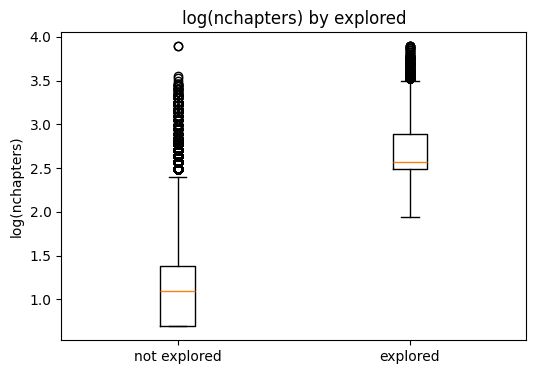

C:\Users\magic\AppData\Local\Temp\ipykernel_7212\82269097.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not explored", "explored"])


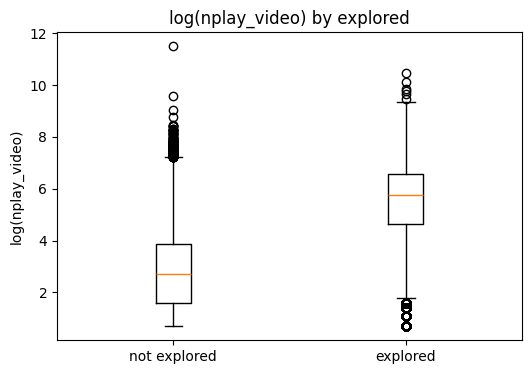

C:\Users\magic\AppData\Local\Temp\ipykernel_7212\82269097.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not explored", "explored"])


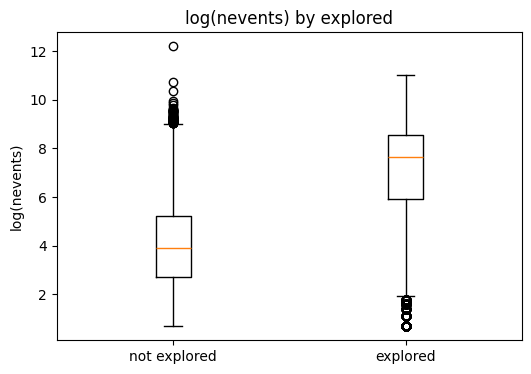

C:\Users\magic\AppData\Local\Temp\ipykernel_7212\82269097.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not explored", "explored"])


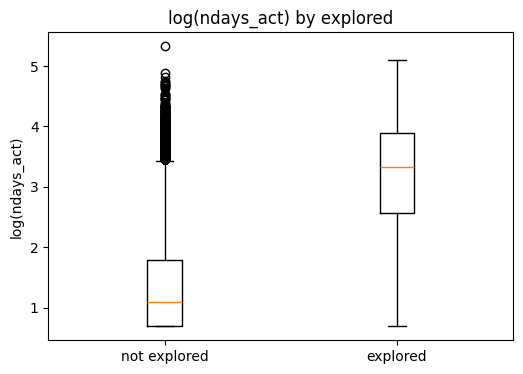

C:\Users\magic\AppData\Local\Temp\ipykernel_7212\82269097.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not explored", "explored"])


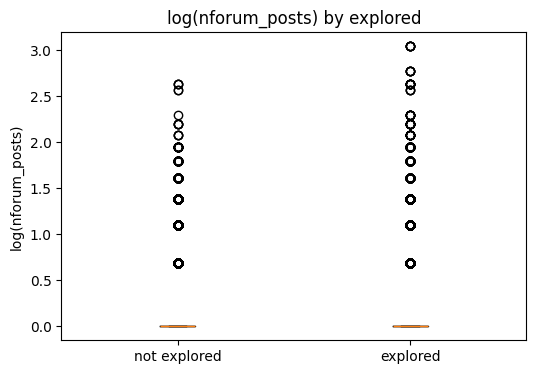

In [56]:
for col in behavior_cols:
    data0 = np.log1p(df_v[df_v["explored"] == 0][col].dropna())
    data1 = np.log1p(df_v[df_v["explored"] == 1][col].dropna())

    plt.figure(figsize=(6,4))
    plt.boxplot([data0, data1], labels=["not explored", "explored"])
    plt.title(f"log({col}) by explored")
    plt.ylabel(f"log({col})")
    plt.grid(False)
    plt.show()

In [59]:
# Cliff’s Delta 효과크기 함수
def cliffs_delta(x, y):
    nx = len(x)
    ny = len(y)

    greater = 0
    less = 0

    for xi in x:
        greater += np.sum(xi > y)
        less += np.sum(xi < y)

    delta = (greater - less) / (nx * ny)
    return delta

In [60]:
from scipy.stats import mannwhitneyu

for col in behavior_cols:
    g0 = df_v[df_v["explored"] == 0][col].dropna()
    g1 = df_v[df_v["explored"] == 1][col].dropna()

    stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
    delta = cliffs_delta(g1, g0)

    print(f"{col}")
    print(f"p-value: {p:.4e}")
    print(f"{col}: Cliff's delta = {delta:.4f}")
    print(f"median (0): {g0.median():.4f}")
    print(f"median (1): {g1.median():.4f}")
    print("-"*40)

nchapters
p-value: 0.0000e+00
nchapters: Cliff's delta = 0.9812
median (0): 2.0000
median (1): 12.0000
----------------------------------------
nplay_video
p-value: 0.0000e+00
nplay_video: Cliff's delta = 0.7557
median (0): 14.0000
median (1): 318.0000
----------------------------------------
nevents
p-value: 0.0000e+00
nevents: Cliff's delta = 0.7434
median (0): 49.0000
median (1): 2127.0000
----------------------------------------
ndays_act
p-value: 0.0000e+00
ndays_act: Cliff's delta = 0.8128
median (0): 2.0000
median (1): 27.0000
----------------------------------------
nforum_posts
p-value: 0.0000e+00
nforum_posts: Cliff's delta = 0.0575
median (0): 0.0000
median (1): 0.0000
----------------------------------------


### explored 단계 전환 요인 분석

Mann-Whitney U 검정 결과, explored 여부에 따라 주요 행동 변수들은 모두 통계적으로 유의한 차이를 보였다 (p < 0.001).

또한 효과크기(Cliff’s Delta)를 확인한 결과, nchapters(≈0.98), ndays_act(≈0.81), nplay_video(≈0.76), nevents(≈0.74) 등 대부분의 행동 변수에서 매우 큰 수준의 효과크기가 나타났다. 특히 nchapters의 경우 거의 완벽에 가까운 분리력을 보이며, explored 여부를 강하게 구분하는 변수로 확인되었다.

이는 explored 단계가 특정 단일 행동에 의해 발생한다기보다, 전반적인 학습 활동 수준이 일정 수준 이상 누적되었을 때 나타나는 결과적 지표임을 시사한다.

한편, nforum_posts의 경우 효과크기가 매우 낮고 중앙값 또한 차이가 없어, 포럼 활동은 explored 여부와 큰 관련이 없는 것으로 나타났다.

In [61]:
df_v.groupby("age_group")["explored"].mean().sort_values()

age_group
under_20    0.106662
20s         0.107230
50s         0.110815
40s         0.113732
30s         0.120369
60_plus     0.132636
unknown     0.140652
Name: explored, dtype: float64

In [62]:
df_v.groupby("LoE_DI")["explored"].mean().sort_values()

LoE_DI
Secondary              0.102427
Bachelor's             0.102854
Less than Secondary    0.113510
Doctorate              0.129717
Master's               0.133697
unknown                0.136912
Name: explored, dtype: float64

In [63]:
df_v.groupby("LoE_DI")["explored"].mean().sort_values()

LoE_DI
Secondary              0.102427
Bachelor's             0.102854
Less than Secondary    0.113510
Doctorate              0.129717
Master's               0.133697
unknown                0.136912
Name: explored, dtype: float64

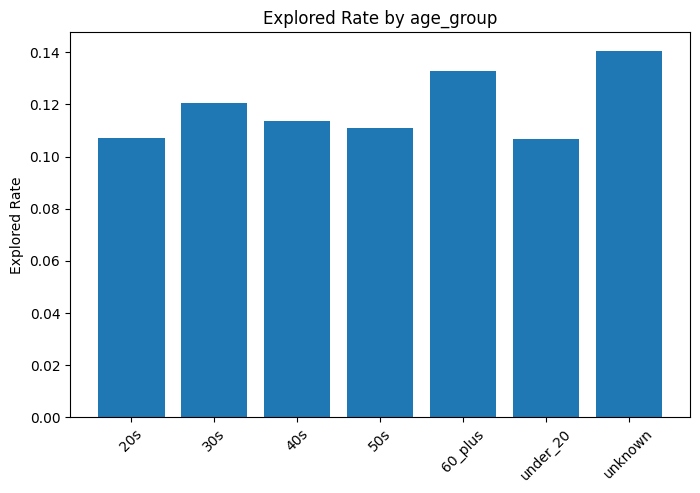

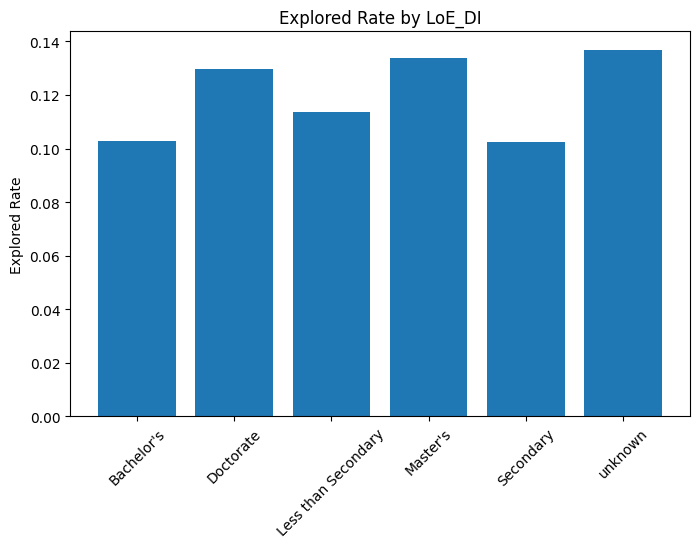

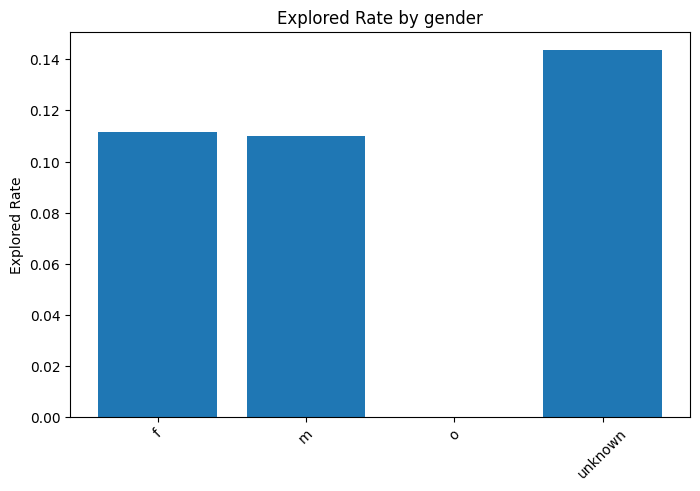

In [64]:
def plot_rate(col):
    temp = df_v.groupby(col)["explored"].mean()

    plt.figure(figsize=(8,5))
    plt.bar(temp.index.astype(str), temp.values)
    plt.title(f"Explored Rate by {col}")
    plt.xticks(rotation=45)
    plt.ylabel("Explored Rate")
    plt.grid(False)
    plt.show()

plot_rate("age_group")
plot_rate("LoE_DI")
plot_rate("gender")

In [69]:
def chi_test(col):
    table = pd.crosstab(df_v[col], df_v["explored"])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col} p-value: {p:.4e}")

def cramers_v(table):
    chi2, _, _, _ = chi2_contingency(table)
    n = table.values.sum()
    return np.sqrt(chi2 / (n * (min(table.shape)-1)))

for col in ["age_group", "LoE_DI", "gender"]:
    table = pd.crosstab(df_v[col], df_v["explored"])
    chi_test(col)
    print(f"효과크기 {col}, {cramers_v(table)}")

age_group p-value: 2.7146e-105
효과크기 age_group, 0.039290710913643216
LoE_DI p-value: 4.1481e-167
효과크기 LoE_DI, 0.049074484428983156
gender p-value: 2.5443e-100
효과크기 gender, 0.03777778904422365


demographic 변수들은 explored 여부와 통계적으로 유의한 관계를 가지지만, 그 효과크기는 매우 작아 실질적인 설명력은 거의 없는 것으로 나타났다.